# A Diffusion Model from Scratch in Pytorch

In this notebook I want to build a very simple (as few code as possible) Diffusion Model for generating Fashion-MNIST images. I will explain all the theoretical details in the YouTube video.


**Sources:**
- Github implementation [Denoising Diffusion Pytorch](https://github.com/lucidrains/denoising-diffusion-pytorch)
- Niels Rogge, Kashif Rasul, [Huggingface notebook](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/annotated_diffusion.ipynb#scrollTo=3a159023)
- Papers on Diffusion models ([Dhariwal, Nichol, 2021], [Ho et al., 2020] ect.)

## Investigating the dataset

As dataset we use Fashion-MNIST, which consists of 60,000 training images and 10,000 test images of clothing items such as shirts, trousers, shoes, bags, and more. Let's see if this is enough to get good results ;-)

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms

def show_images(dataset, num_samples=20, cols=4):
    plt.figure(figsize=(15,15))
    for i, img in enumerate(dataset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img[0].permute(1, 2, 0))

preview_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

data = torchvision.datasets.FashionMNIST(
    root=".",
    train=True,
    download=True,
    transform=preview_transform
)

show_images(data)

Later in this notebook we will do some additional modifications to this dataset, for example make the images smaller, convert them to tensors ect.

# Building the Diffusion Model


## Step 1: The forward process = Noise scheduler




We first need to build the inputs for our model, which are progressively noisier versions of Fashion-MNIST images. Instead of doing this sequentially, we can use the closed form provided in the papers to calculate the image for any of the timesteps individually.

**Key Takeaways**:
- The noise-levels/variances can be pre-computed
- There are different types of variance schedules
- We can sample each timestep image independently (Sums of Gaussians is also Gaussian)
- No model is needed in this forward step

In [2]:
import torch.nn.functional as F
import math

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule from Nichol & Dhariwal (2021).
    Adds noise more gradually than the linear schedule.
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)

def get_index_from_list(vals, t, x_shape):
    """
    Returns a specific index t of a passed list of values vals
    while considering the batch dimension.
    """
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cpu"):
    """
    Takes an image and a timestep as input and
    returns the noisy version of it
    """
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    # mean + variance
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)


# Define beta schedule
T = 200
betas = cosine_beta_schedule(timesteps=T)

# Pre-calculate different terms for closed form
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

Let's test it on our dataset ...

In [3]:
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

IMG_SIZE = 32
BATCH_SIZE = 64

def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1)
    ]

    data_transform = transforms.Compose(data_transforms)

    train = torchvision.datasets.FashionMNIST(
        root=".",
        train=True,
        download=True,
        transform=data_transform
    )

    test = torchvision.datasets.FashionMNIST(
        root=".",
        train=False,
        download=True,
        transform=data_transform
    )

    return torch.utils.data.ConcatDataset([train, test])


def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    if len(image.shape) == 4:
        image = image[0, :, :, :]

    plt.imshow(reverse_transforms(image))


data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


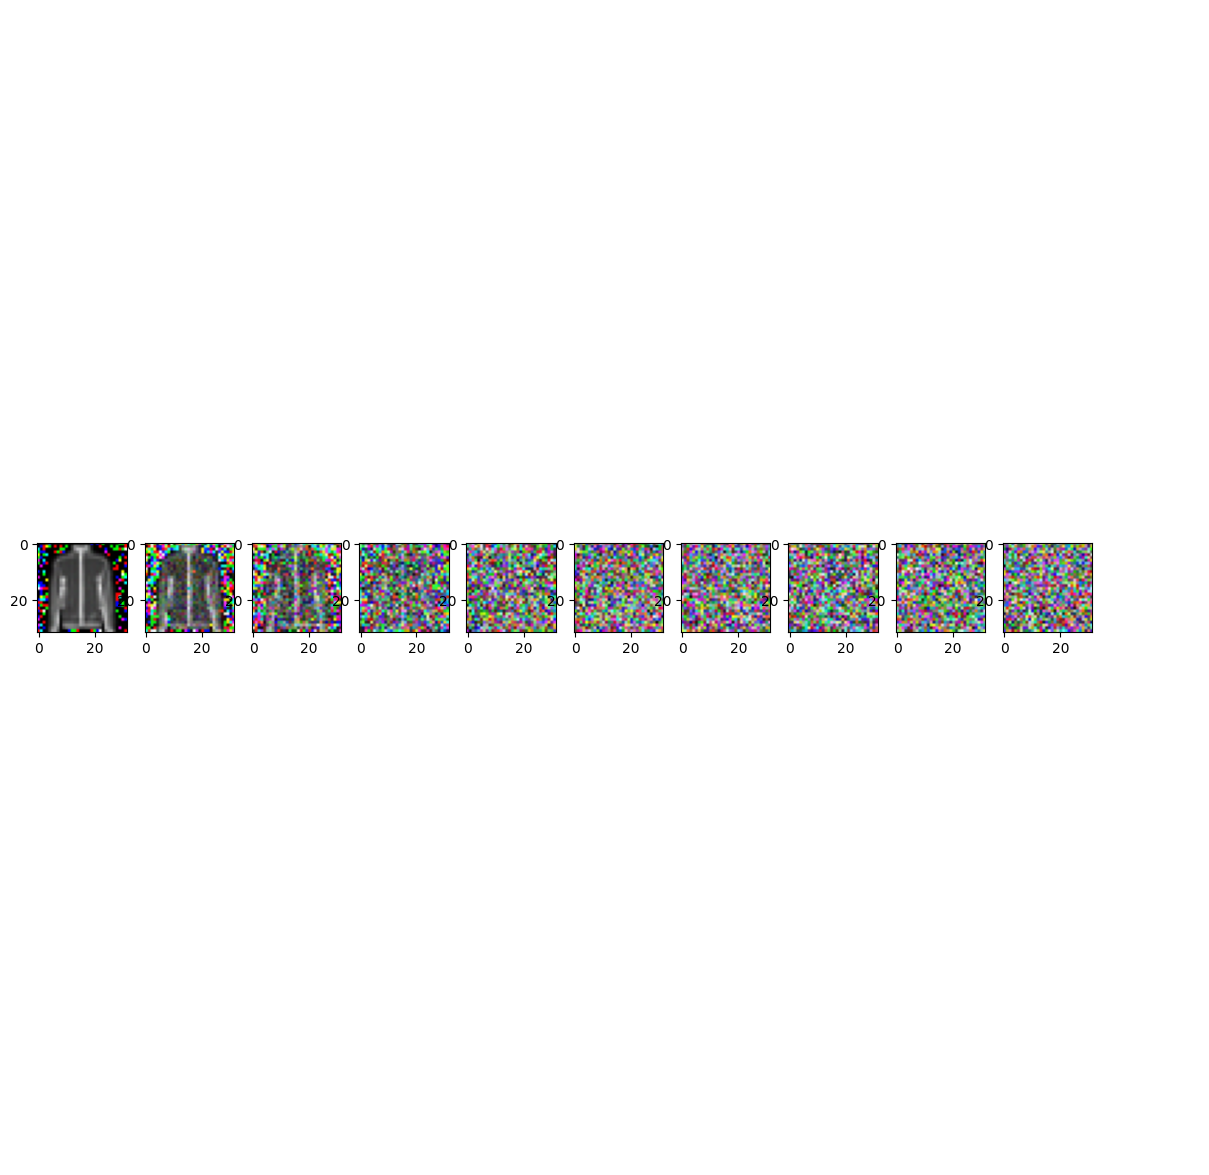

In [4]:
# Simulate forward diffusion
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
    img, noise = forward_diffusion_sample(image, t)
    show_tensor_image(img)

## Step 2: The backward process = U-Net



For a great introduction to UNets, have a look at this post: https://amaarora.github.io/2020/09/13/unet.html.


**Key Takeaways**:
- We use a simple form of a UNet for to predict the noise in the image
- The input is a noisy image, the ouput the noise in the image
- Because the parameters are shared accross time, we need to tell the network in which timestep we are
- The Timestep is encoded by the transformer Sinusoidal Embedding
- We output one single value (mean), because the variance is fixed


In [5]:
from torch import nn
import math


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # GroupNorm is more stable than BatchNorm for varying batch sizes
        self.gnorm1 = nn.GroupNorm(8, out_ch)
        self.gnorm2 = nn.GroupNorm(8, out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        # First Conv
        h = self.gnorm1(self.relu(self.conv1(x)))
        # Time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.gnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class SimpleUnet(nn.Module):
    """
    A simplified variant of the Unet architecture.
    """
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (32, 64, 128, 256, 512)
        up_channels = (512, 256, 128, 64, 32)
        out_dim = 3
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(time_emb_dim),
                nn.Linear(time_emb_dim, time_emb_dim),
                nn.ReLU()
            )

        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1],
                                    time_emb_dim)
                    for i in range(len(down_channels)-1)])
        # Upsample
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1],
                                        time_emb_dim, up=True)
                    for i in range(len(up_channels)-1)])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embed time
        t = self.time_mlp(timestep)
        # Initial conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)

model = SimpleUnet()
print("Num params: ", sum(p.numel() for p in model.parameters()))
model


**Further improvements that can be implemented:**
- Residual connections
- Different activation functions like SiLU, GWLU, ...
- BatchNormalization
- GroupNormalization
- Attention
- ...

## Step 3: The loss



**Key Takeaways:**
- After some maths we end up with a very simple loss function
- There are other possible choices like L2 loss ect.


In [6]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise, noise_pred)

## Sampling
- Without adding @torch.no_grad() we quickly run out of memory, because pytorch tacks all the previous images for gradient calculation
- Because we pre-calculated the noise variances for the forward pass, we also have to use them when we sequentially perform the backward process

In [7]:
@torch.no_grad()
def sample_timestep(x, t):
    """
    Calls the model to predict the noise in the image and returns
    the denoised image.
    Applies noise to this image, if we are not in the last step yet.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)

    if t == 0:
        # As pointed out by Luis Pereira
        # The t's are offset from the t's in the paper
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def sample_plot_image():
    # Sample noise
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    plt.figure(figsize=(15,15))
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        # Edit: This is to maintain the natural range of the distribution
        img = torch.clamp(img, -1.0, 1.0)
        if i % stepsize == 0:
            plt.subplot(1, num_images, int(i/stepsize)+1)
            show_tensor_image(img.detach().cpu())
    plt.show()

## Training


Starting Epoch 1/20
Epoch 1 | Step 0 | Loss: 0.8136
Epoch 1 | Step 100 | Loss: 0.2343
Epoch 1 | Step 200 | Loss: 0.1796
Epoch 1 | Step 300 | Loss: 0.1618
Epoch 1 | Step 400 | Loss: 0.1502
Epoch 1 | Step 500 | Loss: 0.1504


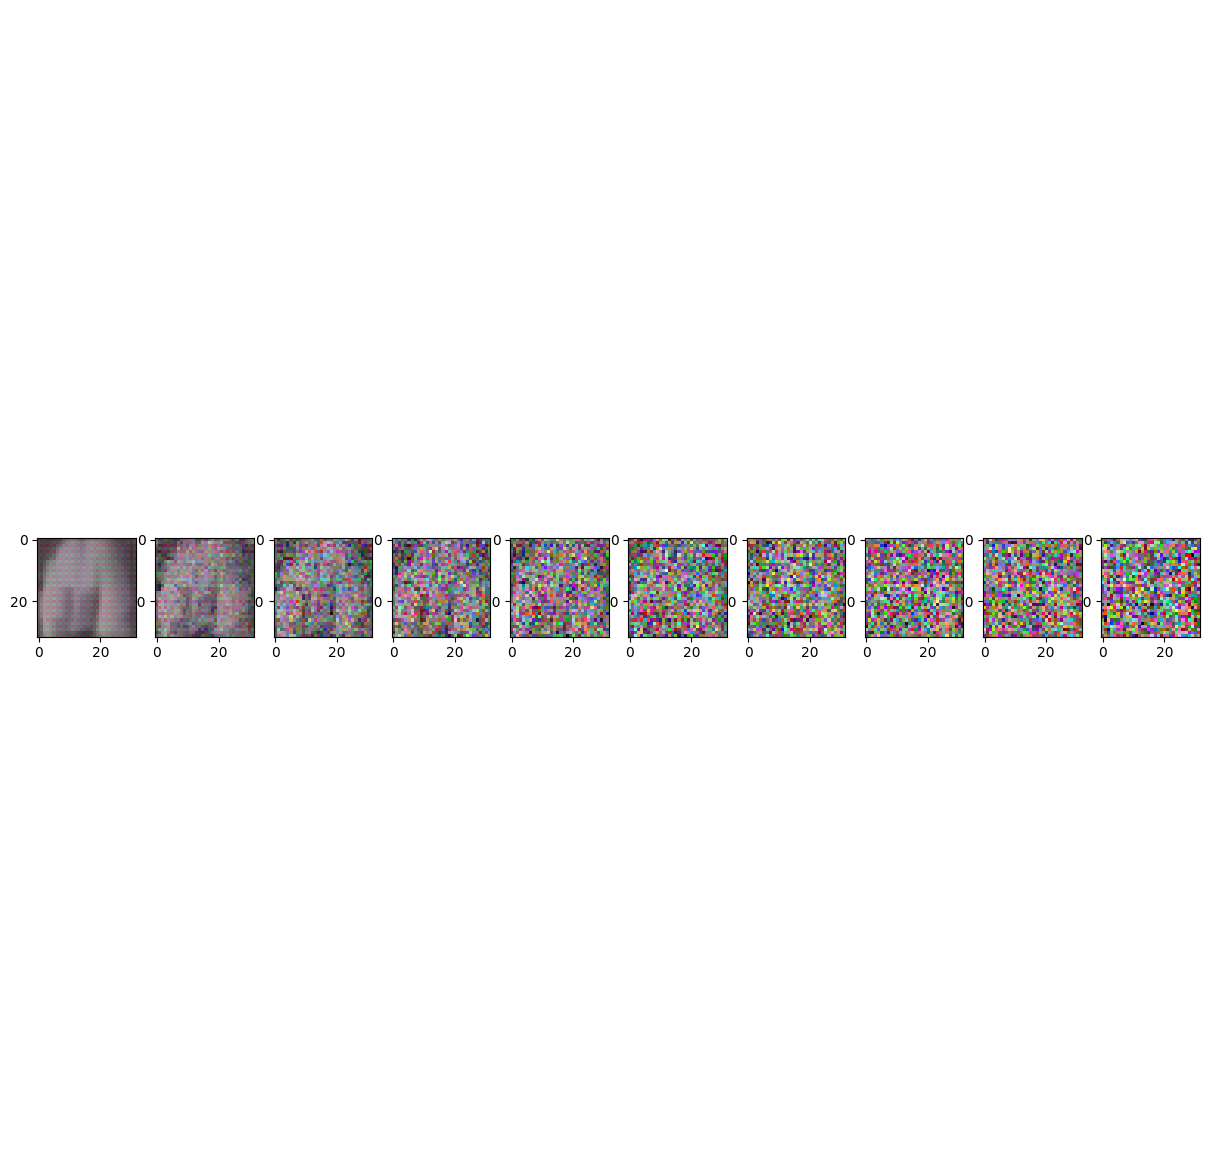


Starting Epoch 2/20
Epoch 2 | Step 0 | Loss: 0.1295
Epoch 2 | Step 100 | Loss: 0.1255
Epoch 2 | Step 200 | Loss: 0.1298
Epoch 2 | Step 300 | Loss: 0.1250
Epoch 2 | Step 400 | Loss: 0.1271
Epoch 2 | Step 500 | Loss: 0.1212


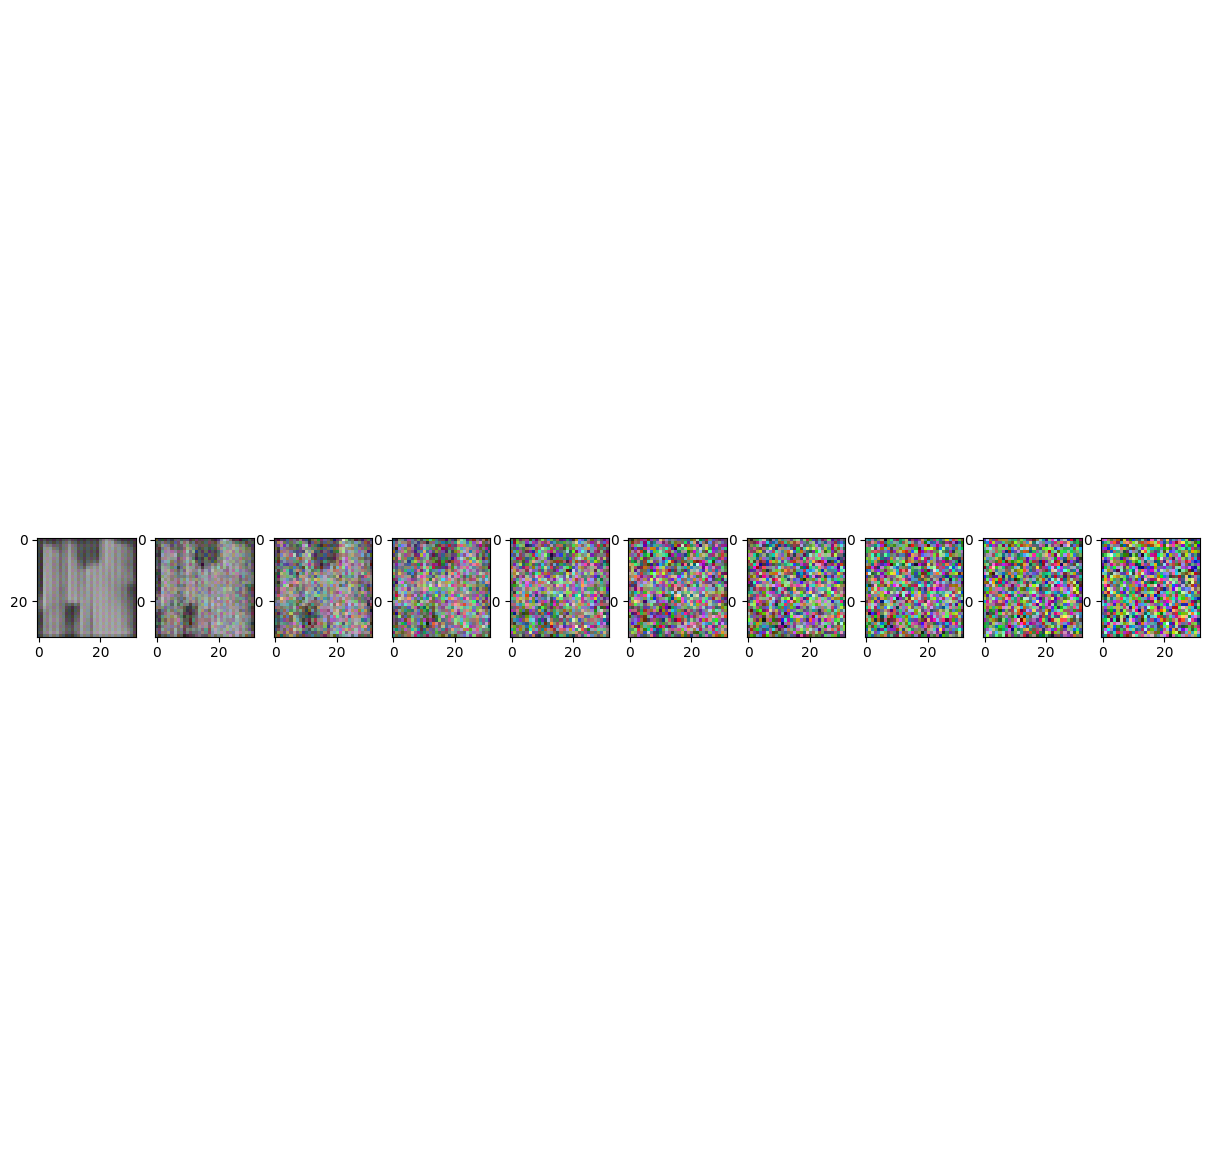


Starting Epoch 3/20
Epoch 3 | Step 0 | Loss: 0.1279
Epoch 3 | Step 100 | Loss: 0.1142
Epoch 3 | Step 200 | Loss: 0.1109
Epoch 3 | Step 300 | Loss: 0.1123
Epoch 3 | Step 400 | Loss: 0.1153
Epoch 3 | Step 500 | Loss: 0.1197


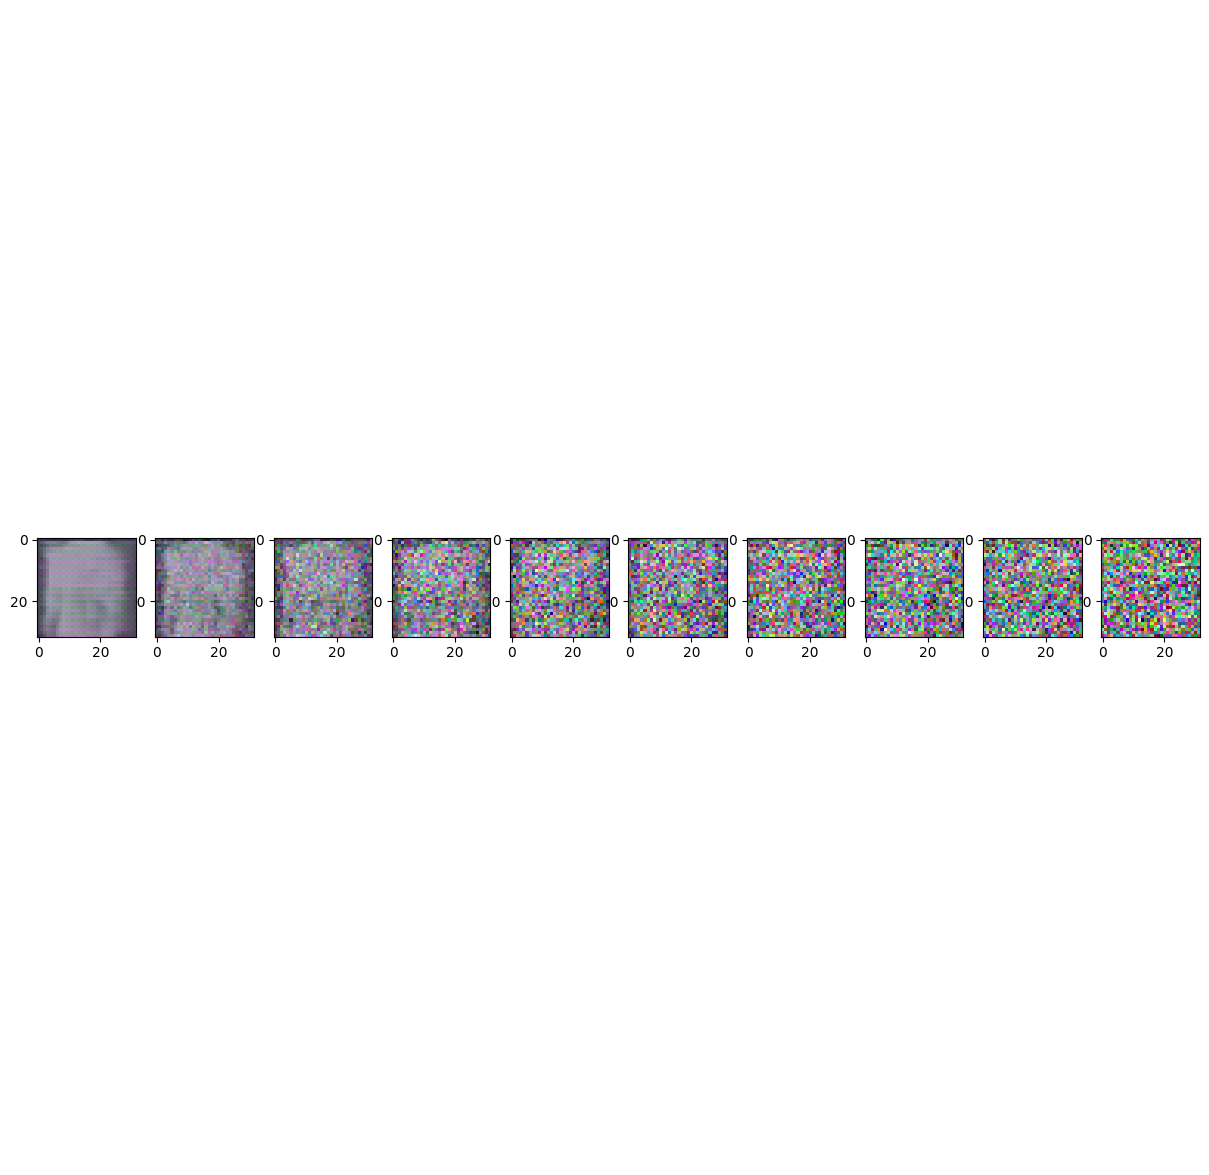


Starting Epoch 4/20
Epoch 4 | Step 0 | Loss: 0.1139
Epoch 4 | Step 100 | Loss: 0.1038
Epoch 4 | Step 200 | Loss: 0.1176
Epoch 4 | Step 300 | Loss: 0.1294
Epoch 4 | Step 400 | Loss: 0.1096
Epoch 4 | Step 500 | Loss: 0.1026


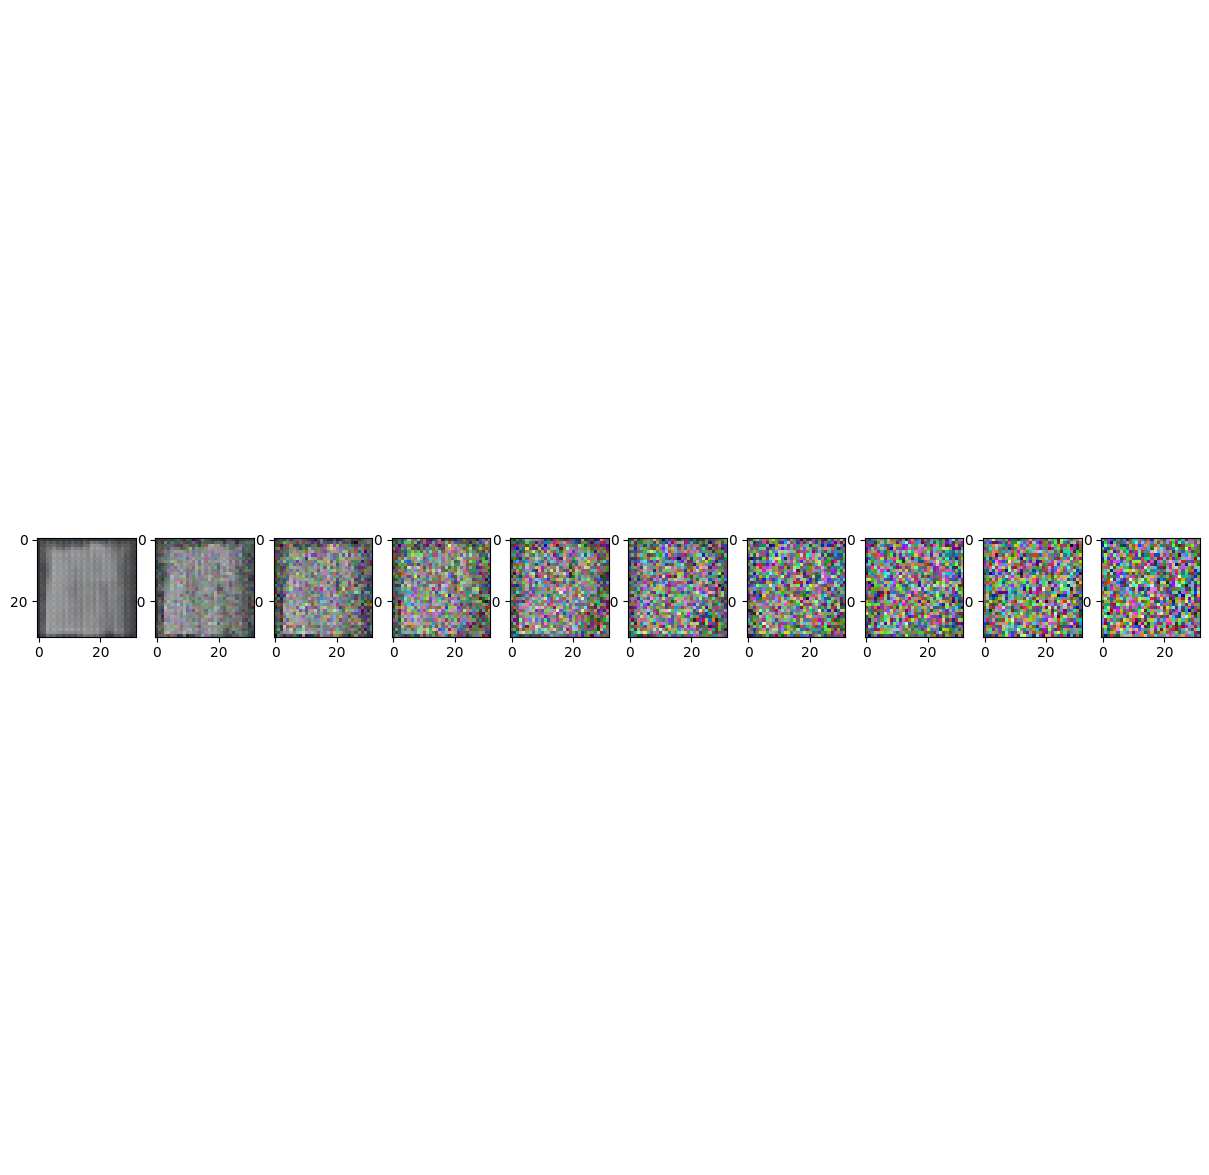


Starting Epoch 5/20
Epoch 5 | Step 0 | Loss: 0.1156
Epoch 5 | Step 100 | Loss: 0.1059
Epoch 5 | Step 200 | Loss: 0.1110
Epoch 5 | Step 300 | Loss: 0.1013
Epoch 5 | Step 400 | Loss: 0.0979
Epoch 5 | Step 500 | Loss: 0.0968


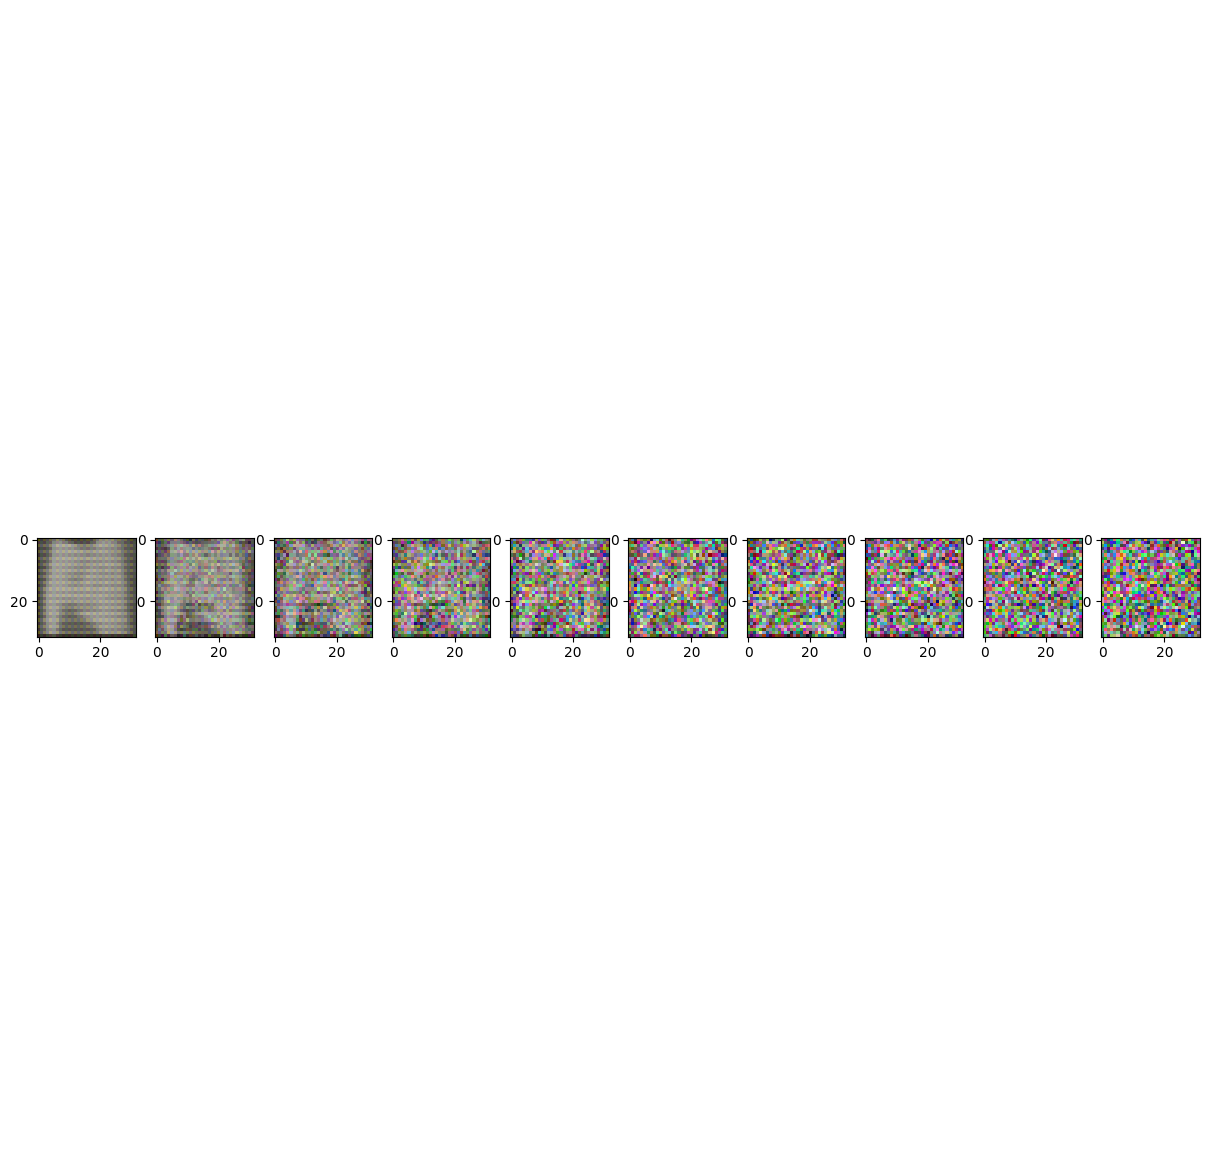


Starting Epoch 6/20
Epoch 6 | Step 0 | Loss: 0.1073
Epoch 6 | Step 100 | Loss: 0.0995
Epoch 6 | Step 200 | Loss: 0.1074
Epoch 6 | Step 300 | Loss: 0.1030
Epoch 6 | Step 400 | Loss: 0.0895
Epoch 6 | Step 500 | Loss: 0.0936


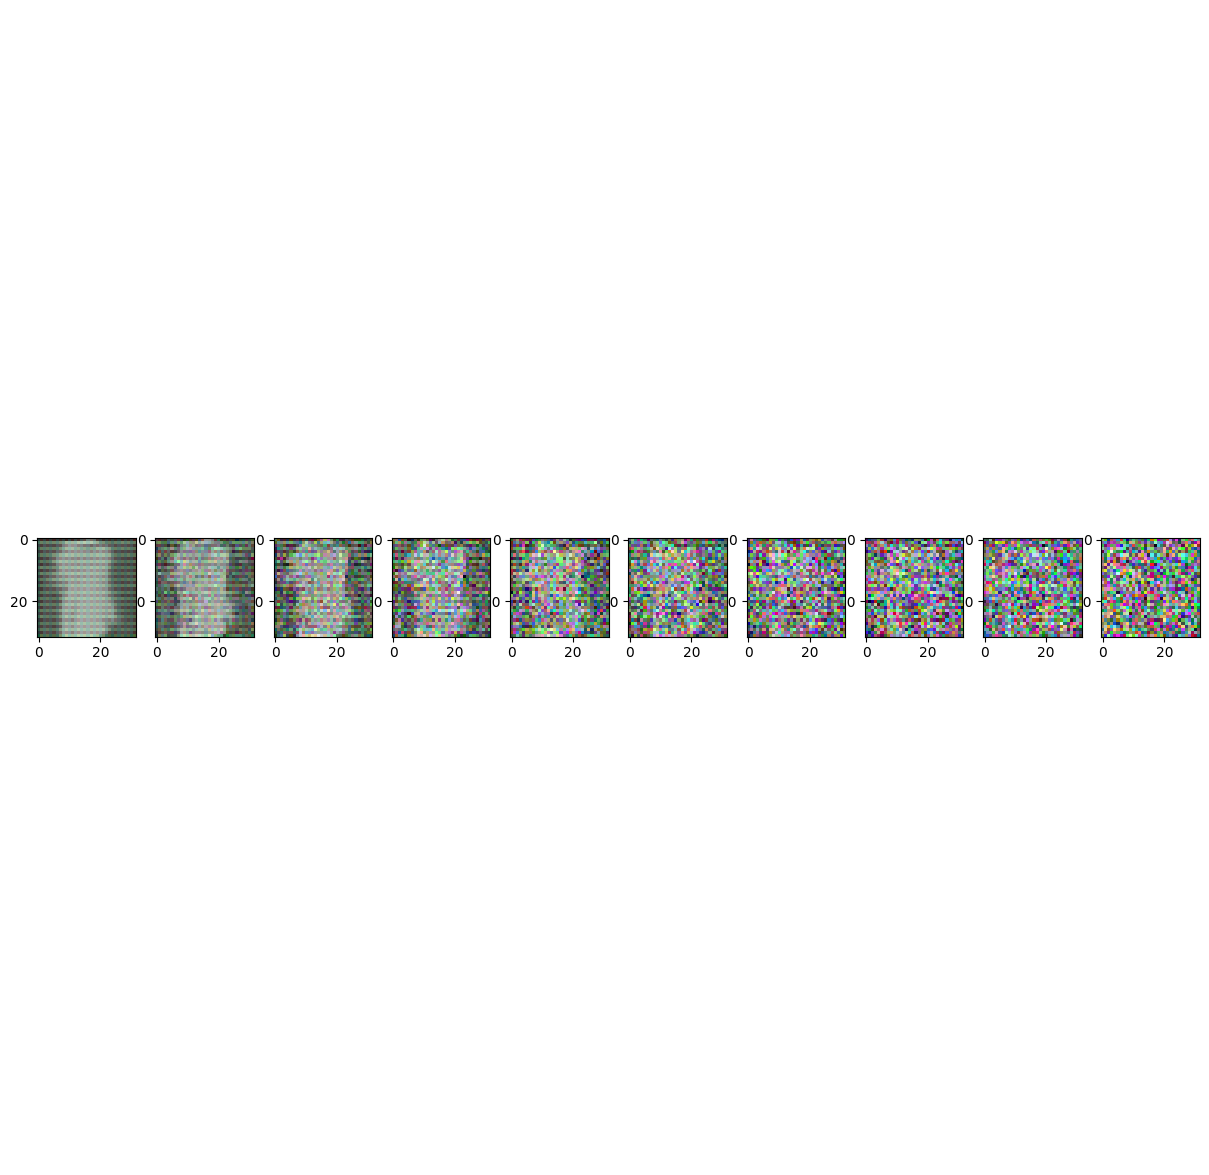


Starting Epoch 7/20
Epoch 7 | Step 0 | Loss: 0.1026
Epoch 7 | Step 100 | Loss: 0.0957
Epoch 7 | Step 200 | Loss: 0.0980
Epoch 7 | Step 300 | Loss: 0.0886
Epoch 7 | Step 400 | Loss: 0.0981
Epoch 7 | Step 500 | Loss: 0.0925


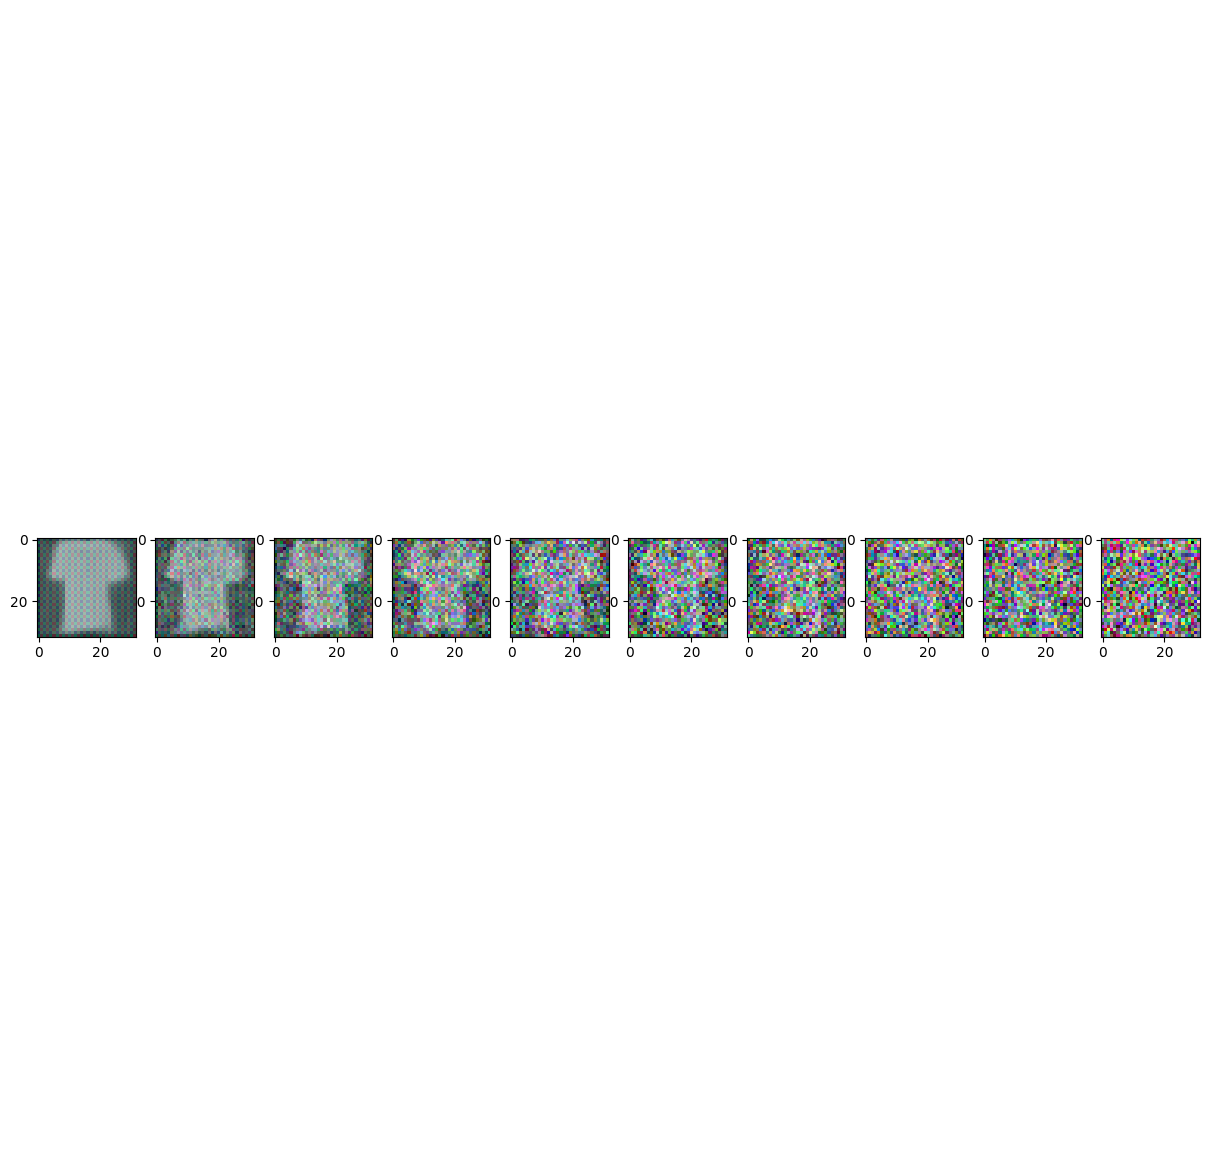


Starting Epoch 8/20
Epoch 8 | Step 0 | Loss: 0.0974
Epoch 8 | Step 100 | Loss: 0.1005
Epoch 8 | Step 200 | Loss: 0.0924
Epoch 8 | Step 300 | Loss: 0.1038
Epoch 8 | Step 400 | Loss: 0.0969
Epoch 8 | Step 500 | Loss: 0.0891


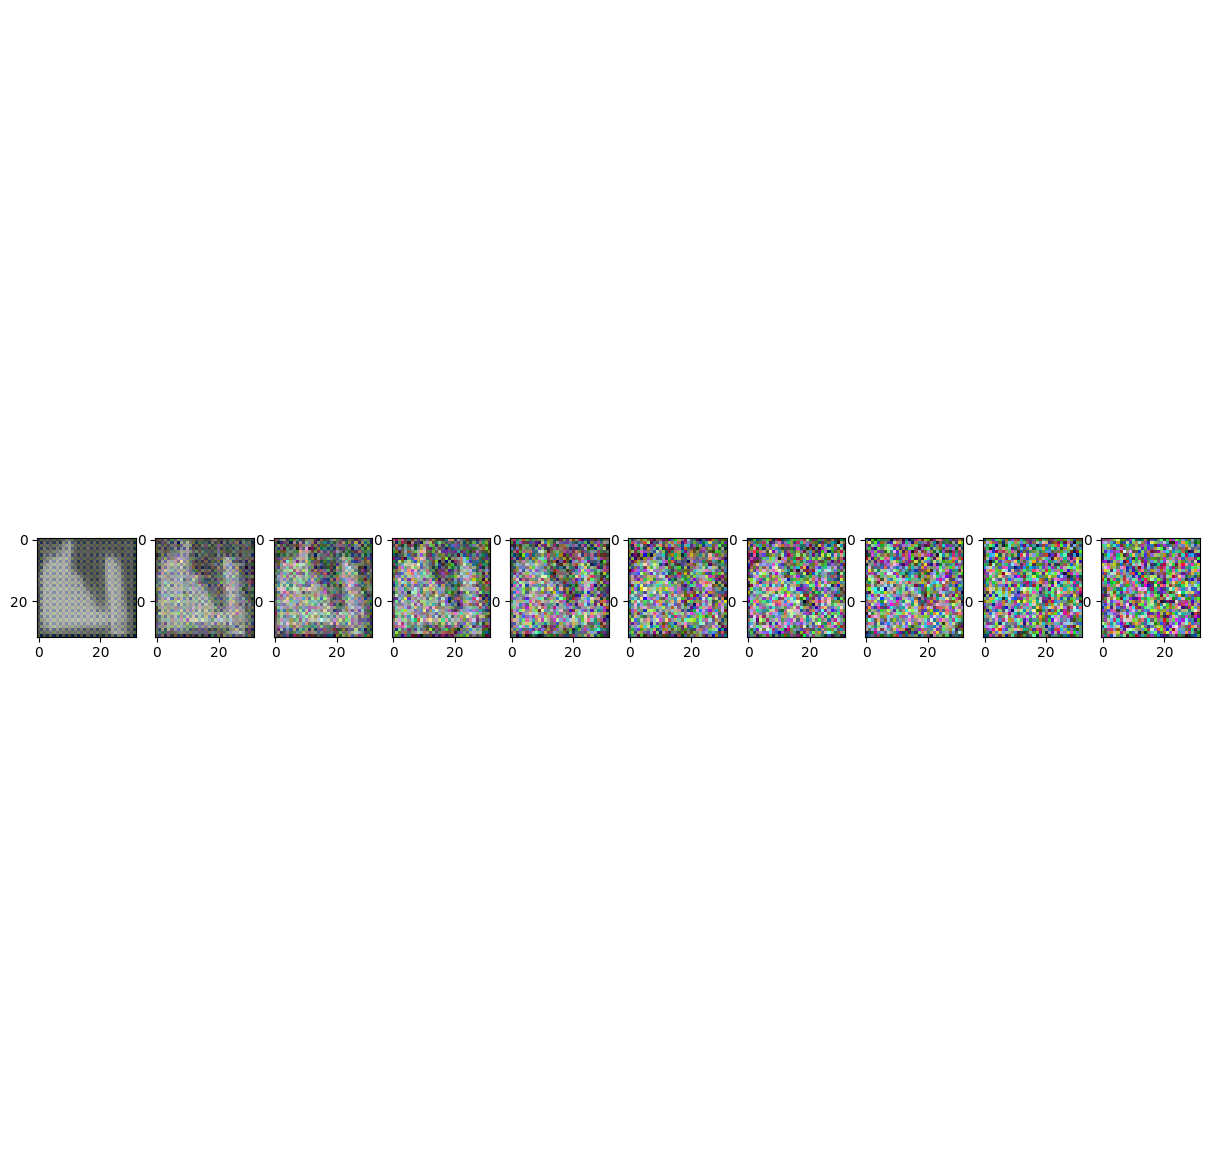


Starting Epoch 9/20
Epoch 9 | Step 0 | Loss: 0.0939
Epoch 9 | Step 100 | Loss: 0.0902
Epoch 9 | Step 200 | Loss: 0.0938
Epoch 9 | Step 300 | Loss: 0.0984
Epoch 9 | Step 400 | Loss: 0.0918
Epoch 9 | Step 500 | Loss: 0.0987


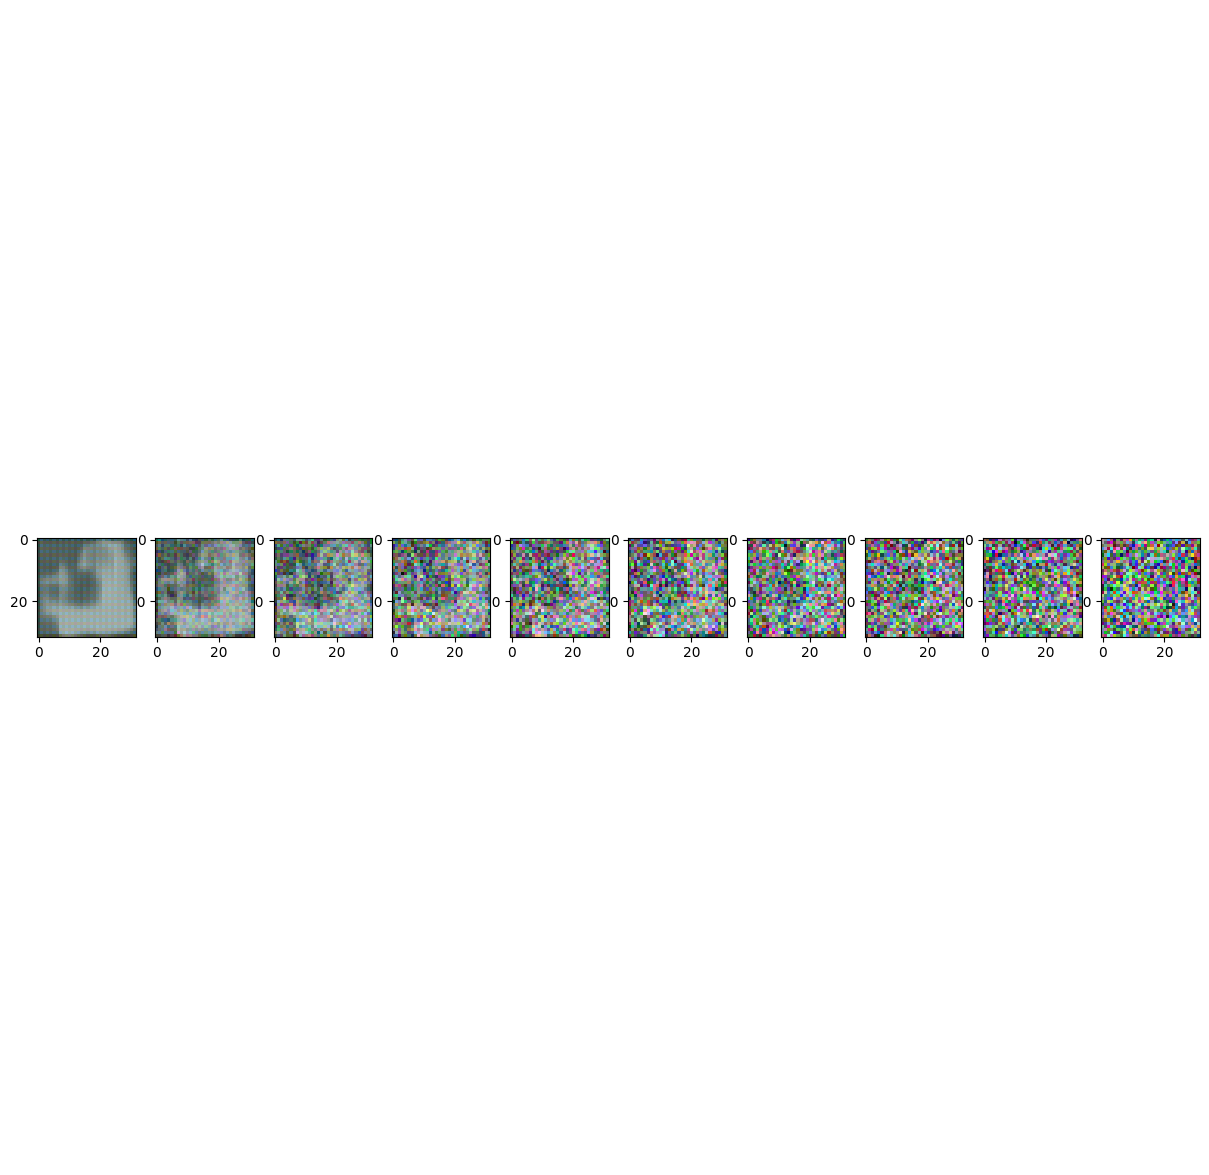


Starting Epoch 10/20
Epoch 10 | Step 0 | Loss: 0.0940
Epoch 10 | Step 100 | Loss: 0.0930
Epoch 10 | Step 200 | Loss: 0.0917
Epoch 10 | Step 300 | Loss: 0.0951
Epoch 10 | Step 400 | Loss: 0.0992
Epoch 10 | Step 500 | Loss: 0.0909


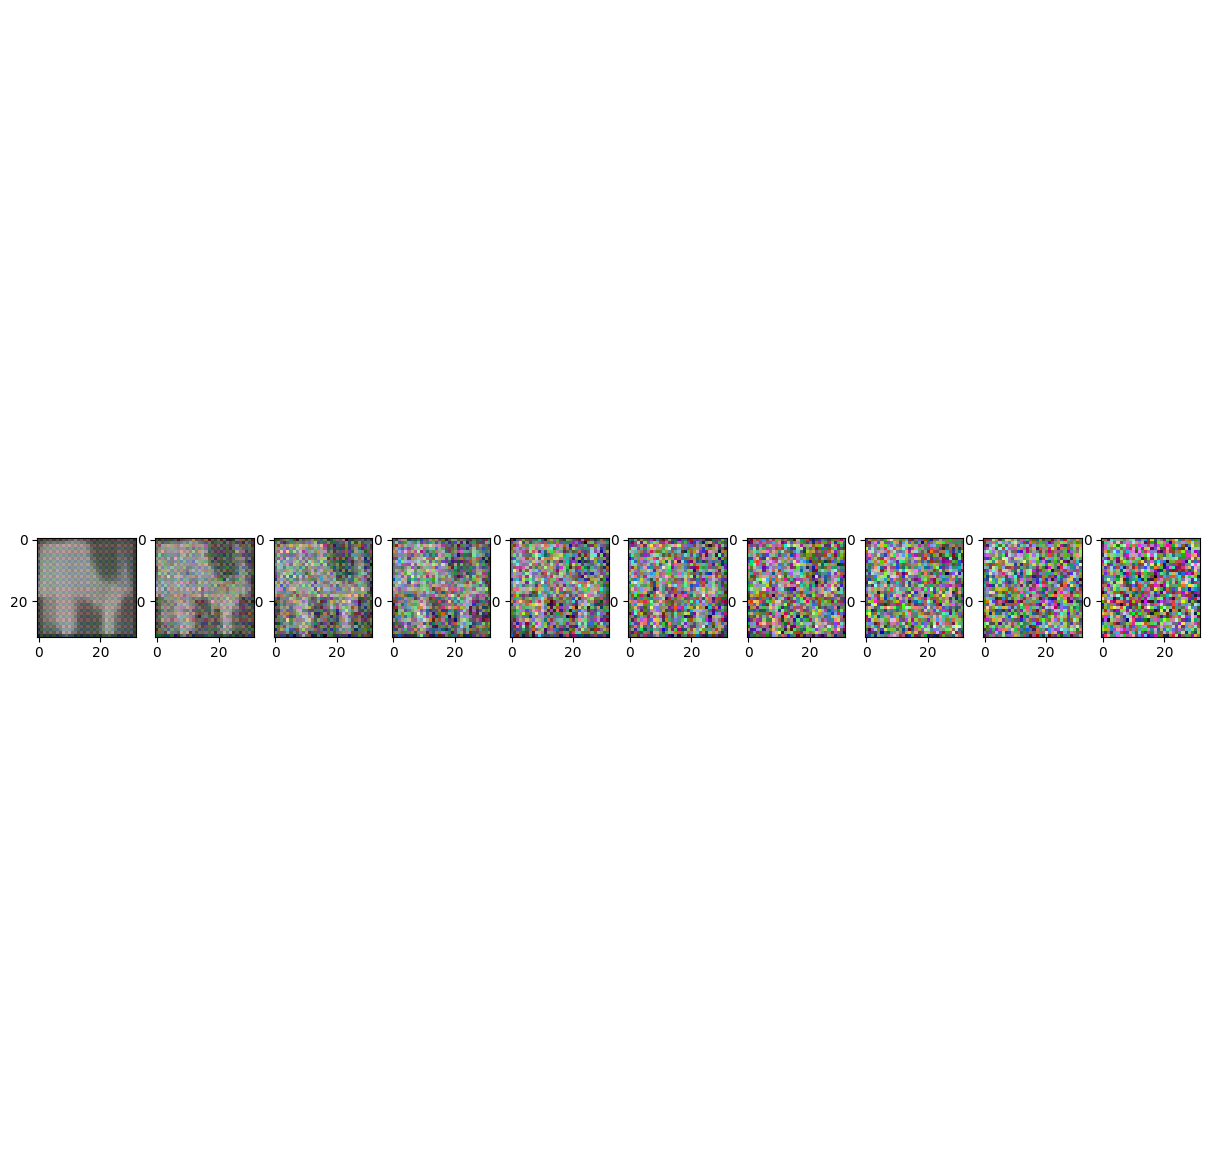


Starting Epoch 11/20
Epoch 11 | Step 0 | Loss: 0.0971
Epoch 11 | Step 100 | Loss: 0.0882
Epoch 11 | Step 200 | Loss: 0.0877
Epoch 11 | Step 300 | Loss: 0.0890
Epoch 11 | Step 400 | Loss: 0.0864
Epoch 11 | Step 500 | Loss: 0.0932


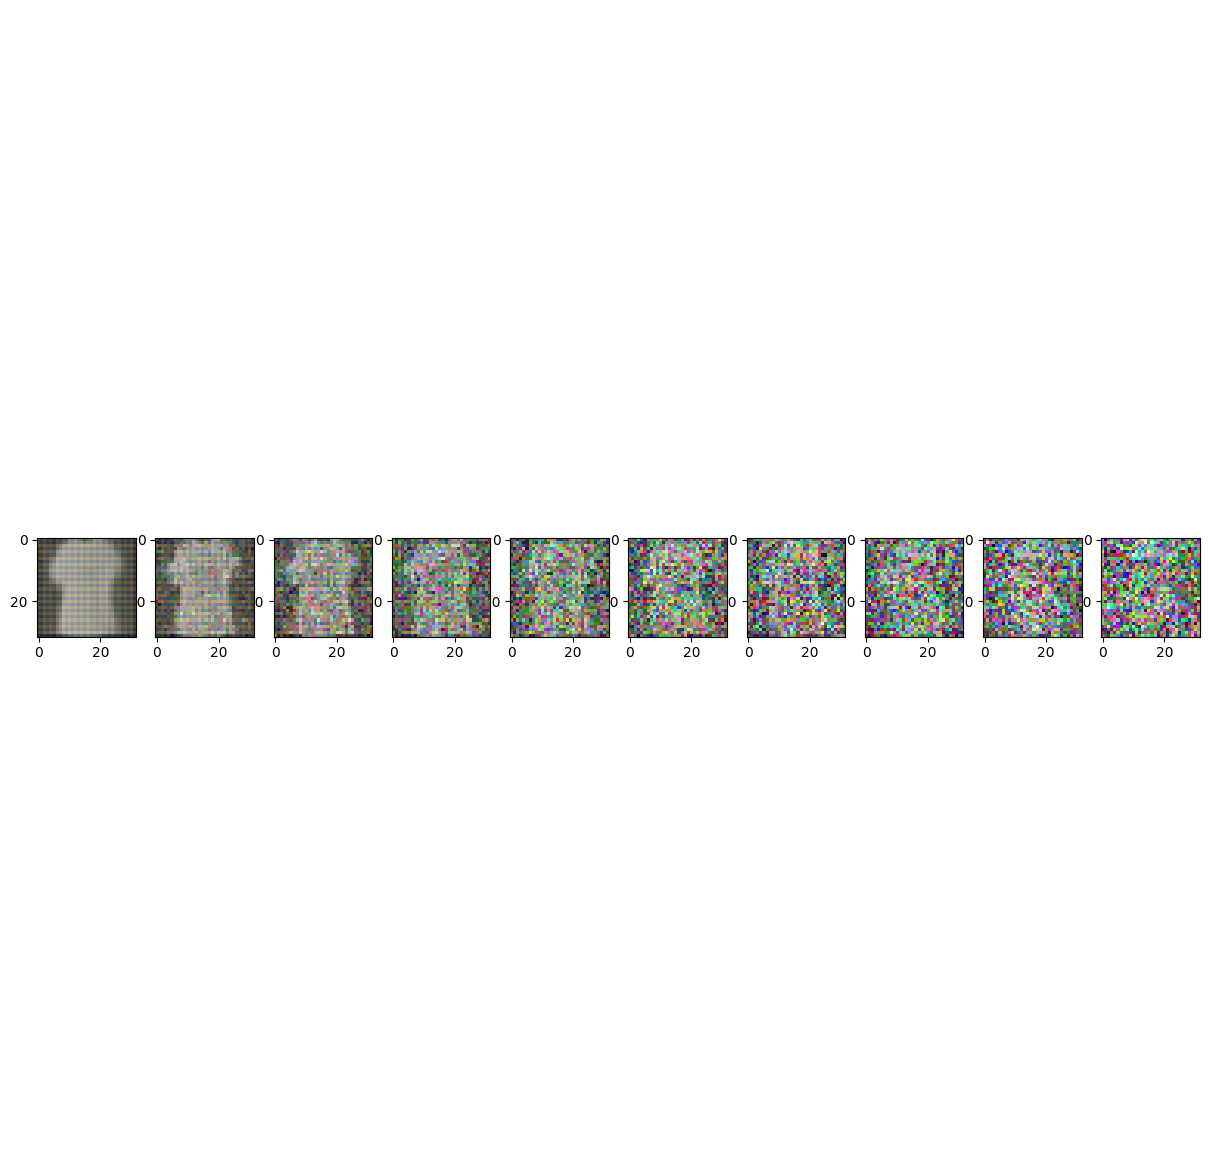


Starting Epoch 12/20
Epoch 12 | Step 0 | Loss: 0.0909
Epoch 12 | Step 100 | Loss: 0.0925
Epoch 12 | Step 200 | Loss: 0.0886
Epoch 12 | Step 300 | Loss: 0.0934
Epoch 12 | Step 400 | Loss: 0.0975
Epoch 12 | Step 500 | Loss: 0.0846


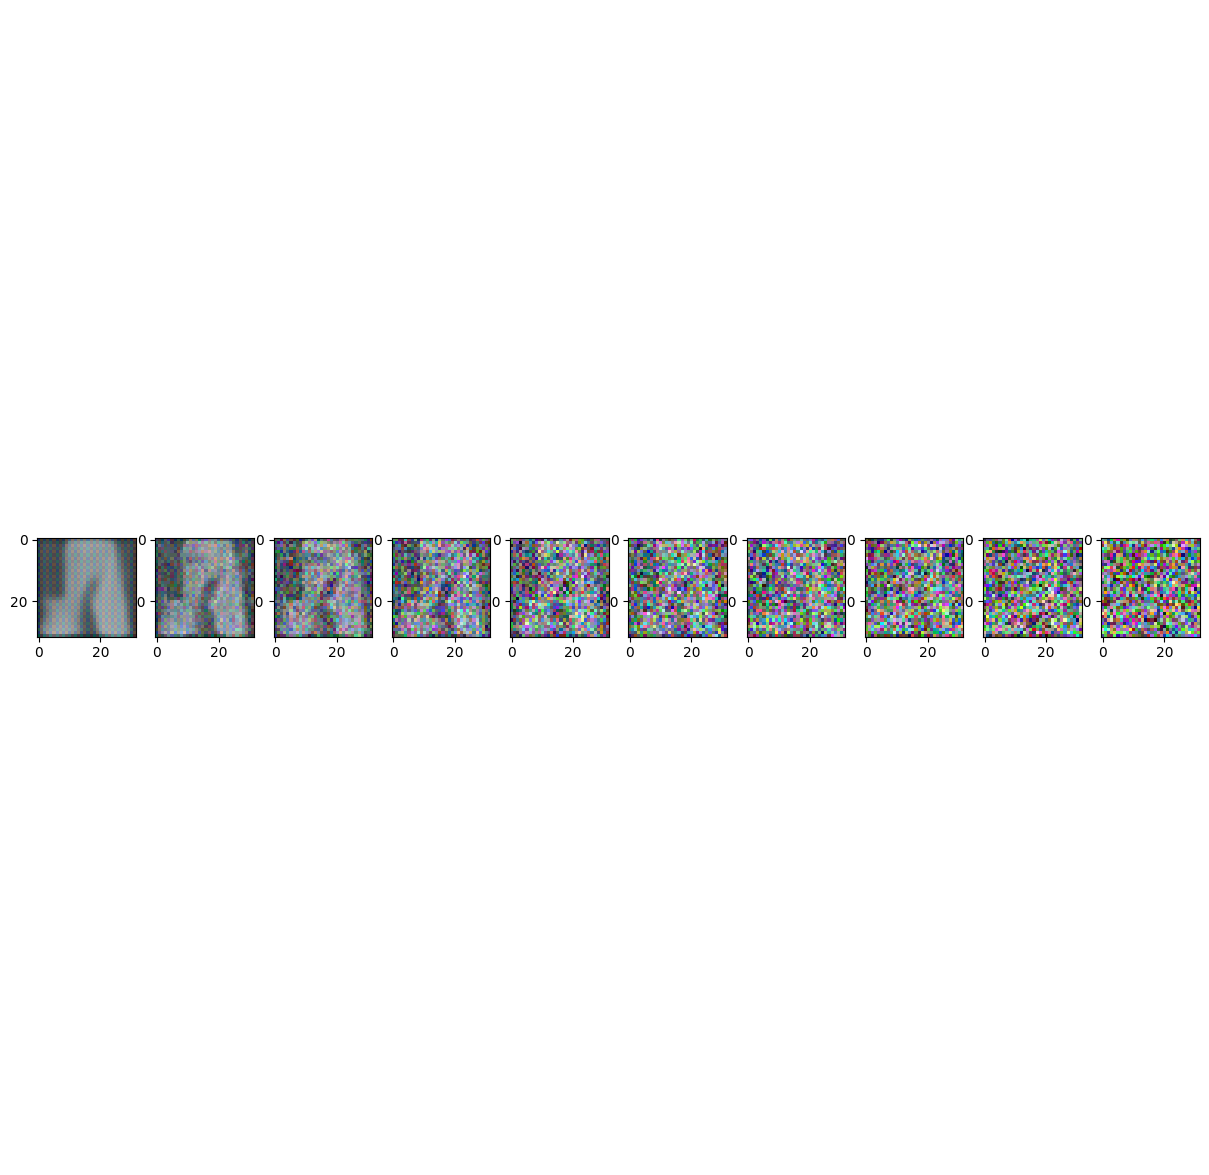


Starting Epoch 13/20
Epoch 13 | Step 0 | Loss: 0.0870
Epoch 13 | Step 100 | Loss: 0.0909
Epoch 13 | Step 200 | Loss: 0.0949
Epoch 13 | Step 300 | Loss: 0.0819
Epoch 13 | Step 400 | Loss: 0.0931
Epoch 13 | Step 500 | Loss: 0.0854


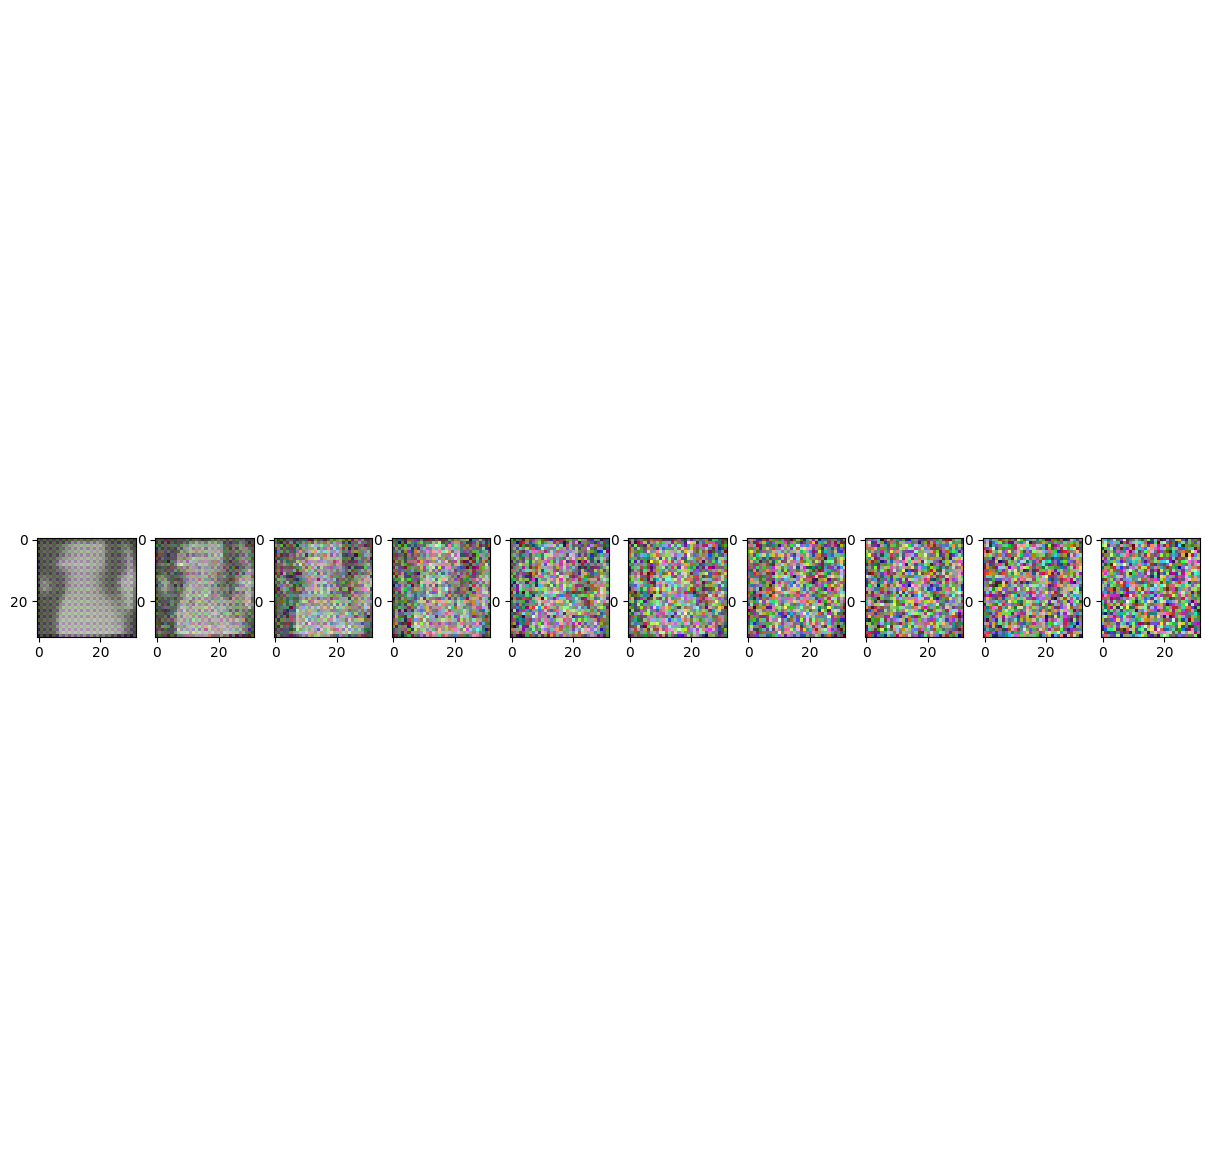


Starting Epoch 14/20
Epoch 14 | Step 0 | Loss: 0.0885
Epoch 14 | Step 100 | Loss: 0.0850
Epoch 14 | Step 200 | Loss: 0.0889
Epoch 14 | Step 300 | Loss: 0.0891
Epoch 14 | Step 400 | Loss: 0.0819
Epoch 14 | Step 500 | Loss: 0.0843


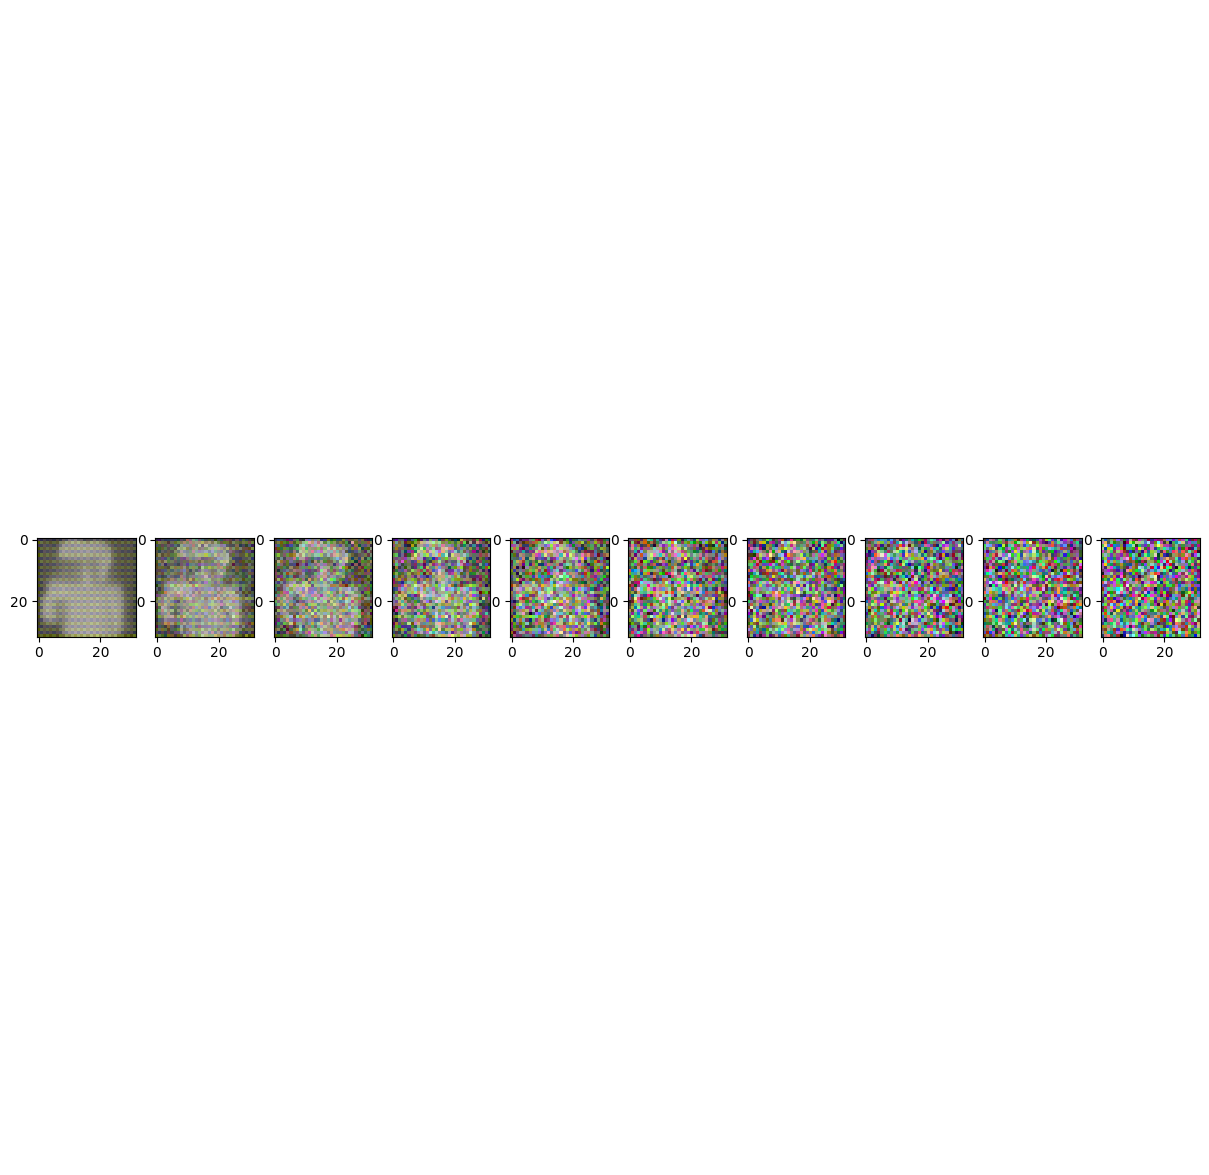


Starting Epoch 15/20
Epoch 15 | Step 0 | Loss: 0.0868
Epoch 15 | Step 100 | Loss: 0.0939
Epoch 15 | Step 200 | Loss: 0.0870
Epoch 15 | Step 300 | Loss: 0.0907
Epoch 15 | Step 400 | Loss: 0.0907
Epoch 15 | Step 500 | Loss: 0.0903


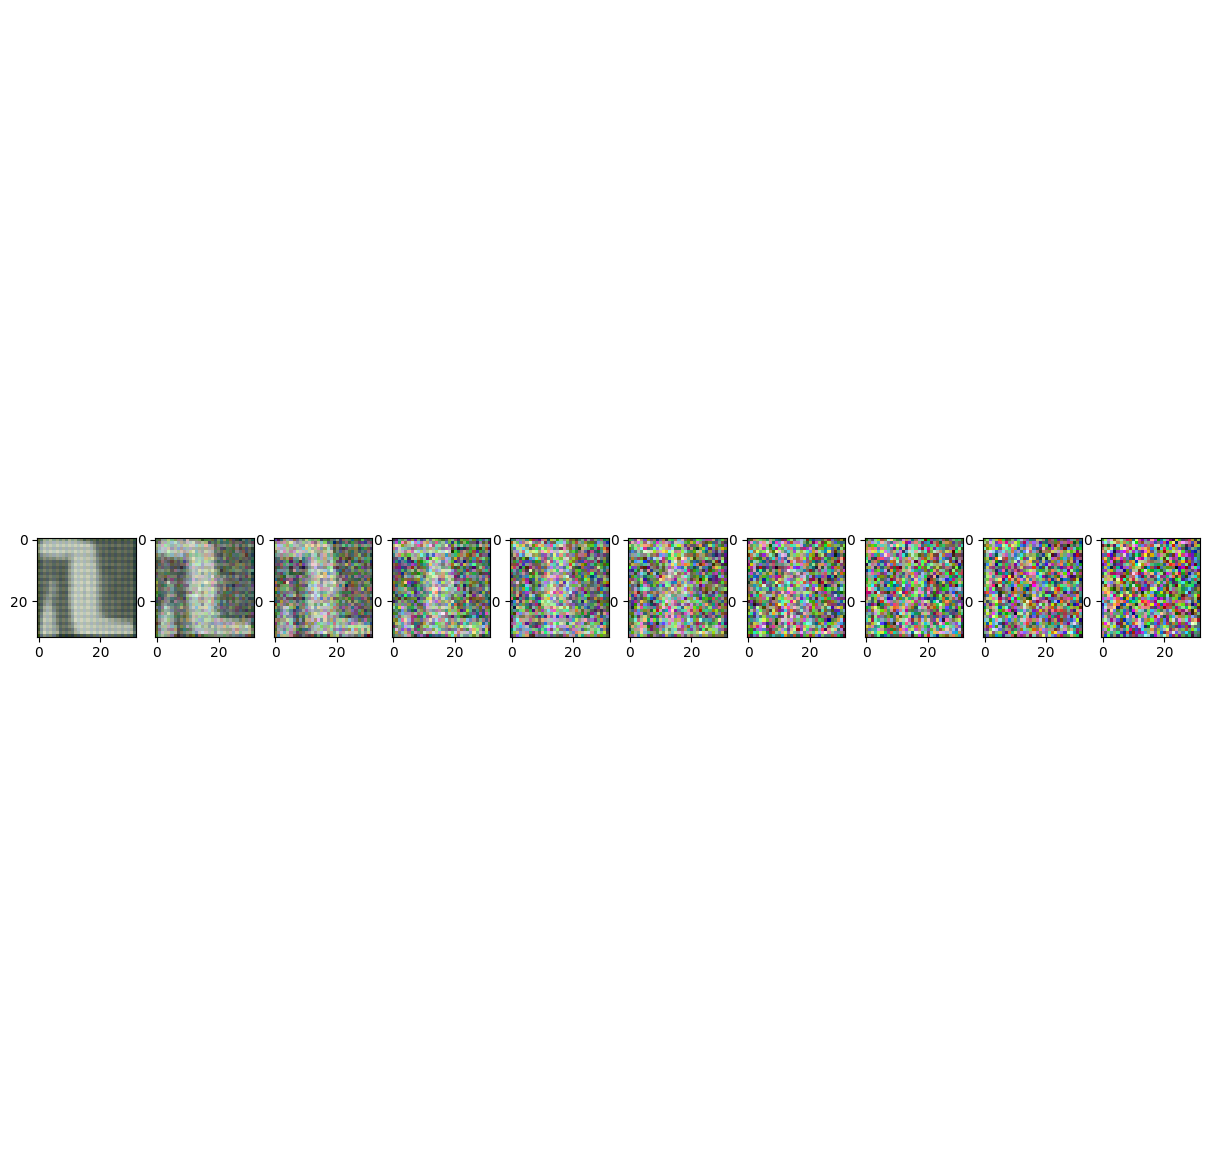


Starting Epoch 16/20
Epoch 16 | Step 0 | Loss: 0.0872
Epoch 16 | Step 100 | Loss: 0.0852
Epoch 16 | Step 200 | Loss: 0.0932
Epoch 16 | Step 300 | Loss: 0.0895
Epoch 16 | Step 400 | Loss: 0.0944
Epoch 16 | Step 500 | Loss: 0.0888


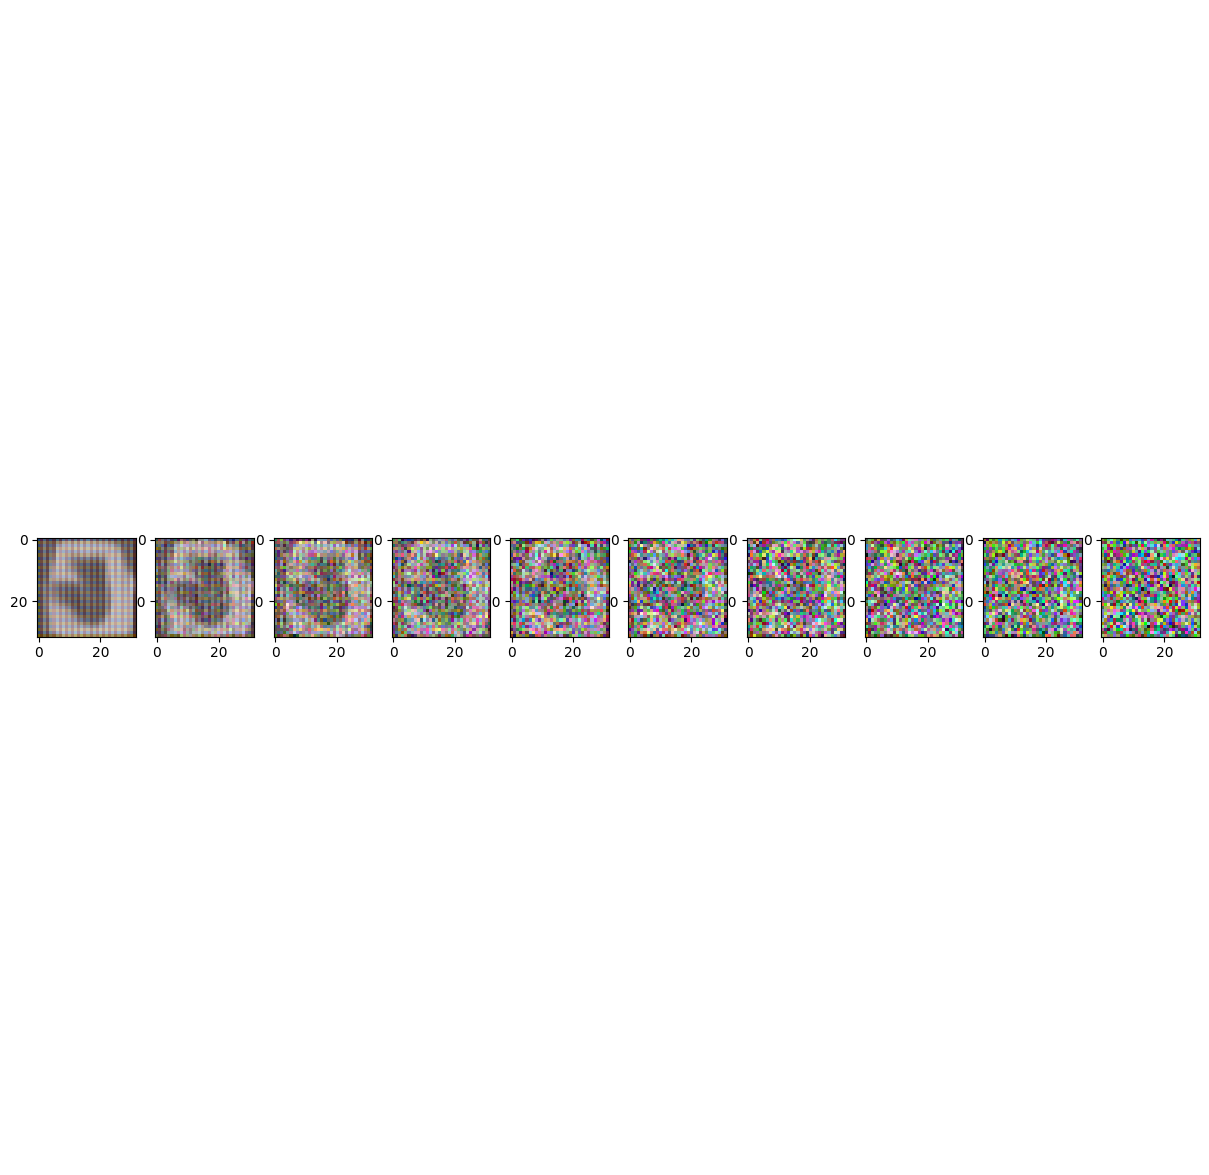


Starting Epoch 17/20
Epoch 17 | Step 0 | Loss: 0.0882
Epoch 17 | Step 100 | Loss: 0.0880
Epoch 17 | Step 200 | Loss: 0.0834
Epoch 17 | Step 300 | Loss: 0.0930
Epoch 17 | Step 400 | Loss: 0.0874
Epoch 17 | Step 500 | Loss: 0.0878


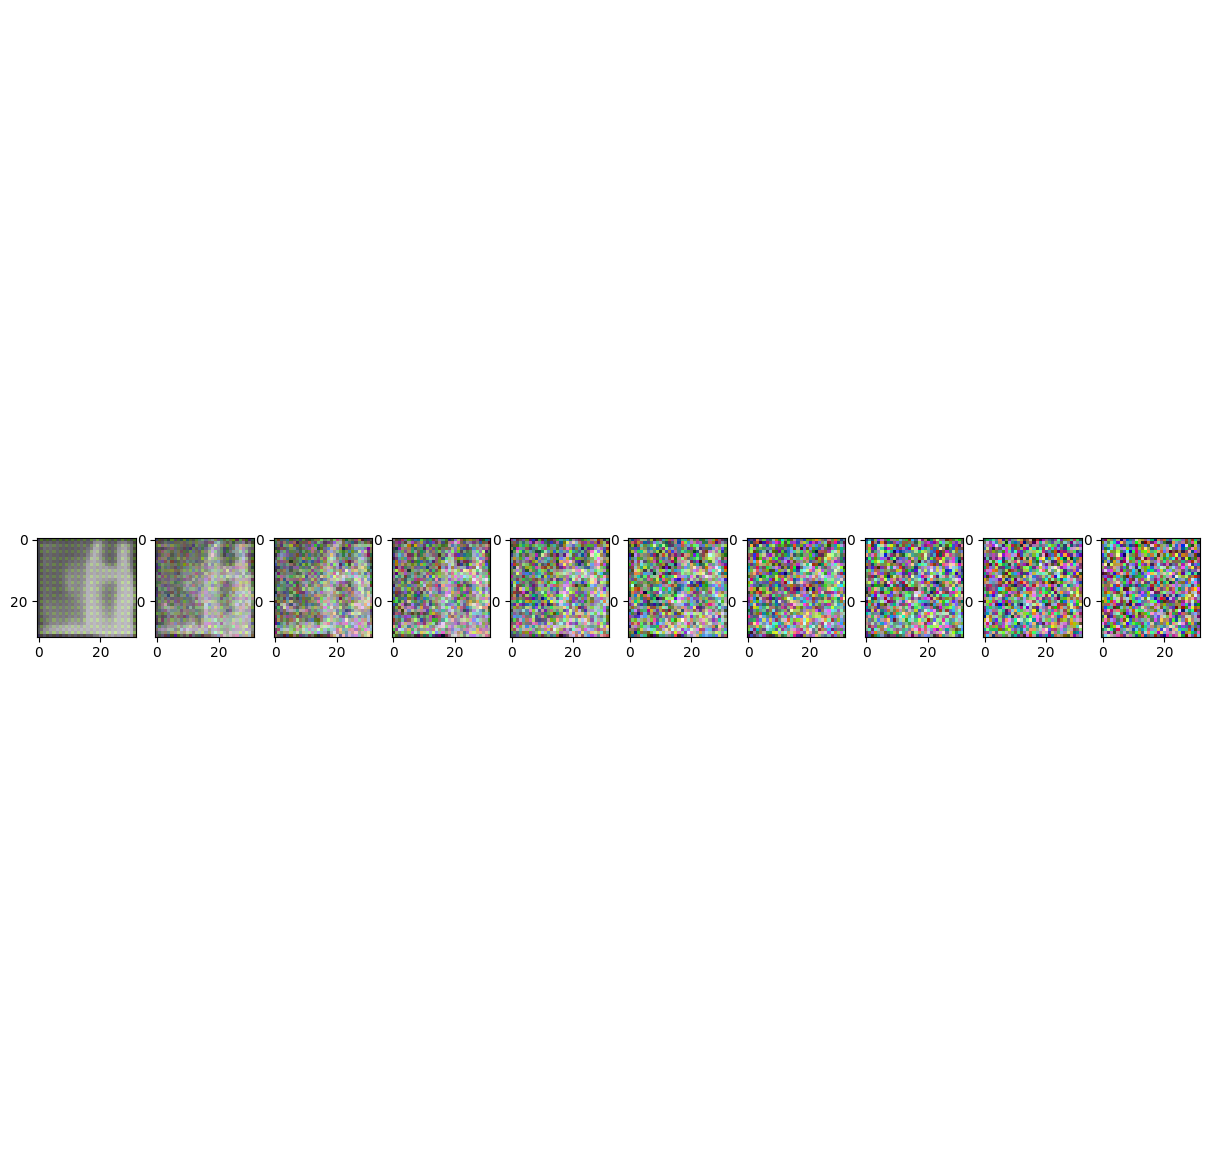


Starting Epoch 18/20
Epoch 18 | Step 0 | Loss: 0.0852
Epoch 18 | Step 100 | Loss: 0.0847
Epoch 18 | Step 200 | Loss: 0.0931
Epoch 18 | Step 300 | Loss: 0.0828
Epoch 18 | Step 400 | Loss: 0.0828
Epoch 18 | Step 500 | Loss: 0.0840


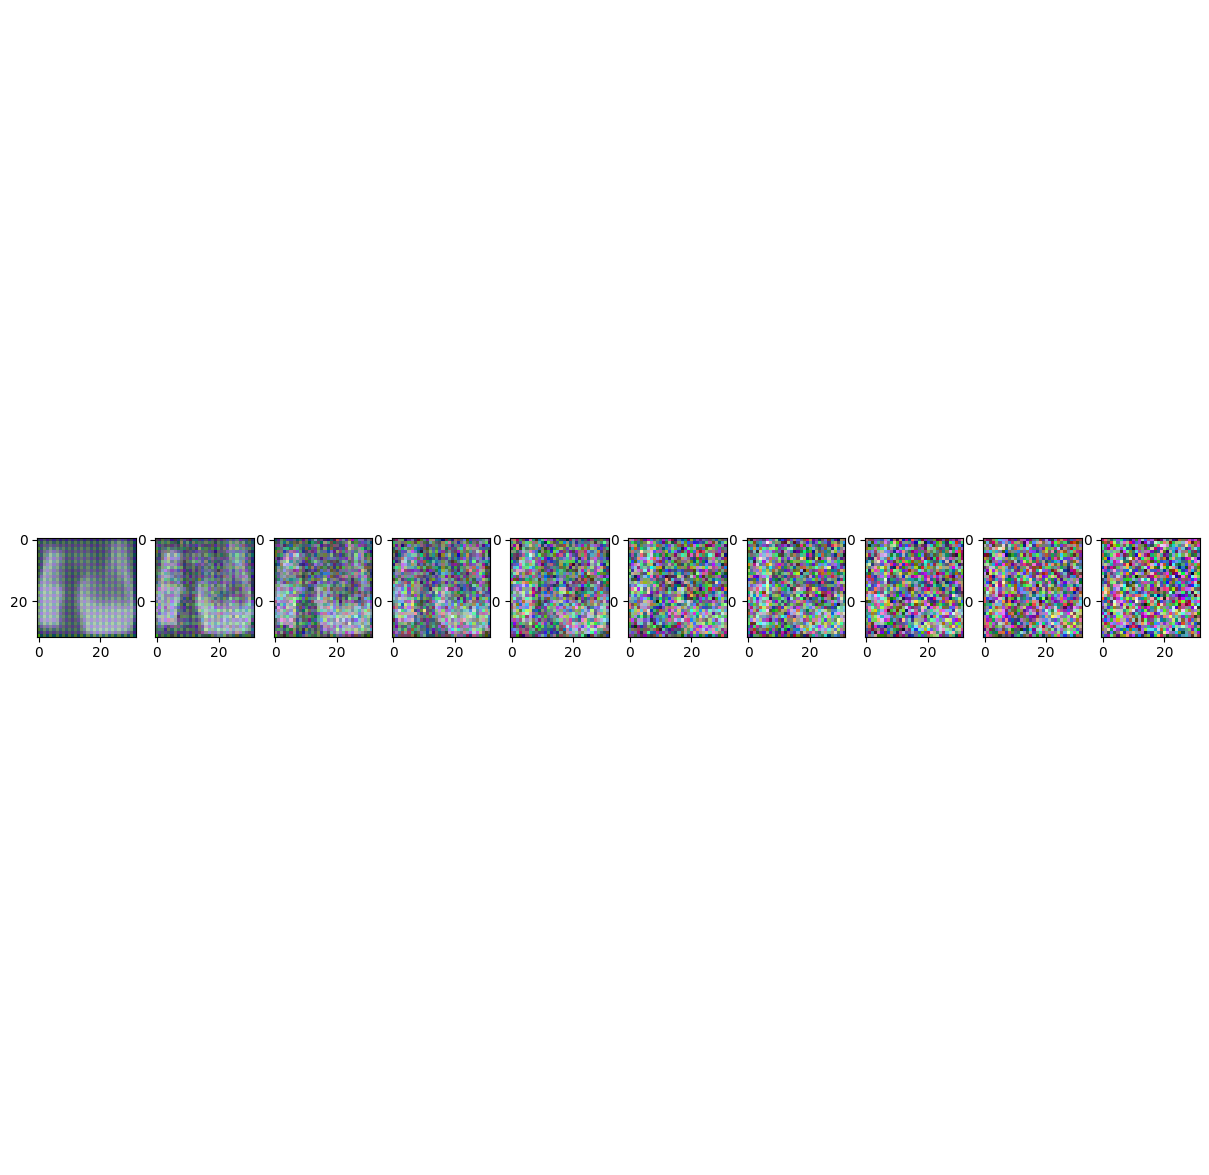


Starting Epoch 19/20
Epoch 19 | Step 0 | Loss: 0.0948
Epoch 19 | Step 100 | Loss: 0.0889
Epoch 19 | Step 200 | Loss: 0.0854
Epoch 19 | Step 300 | Loss: 0.0899
Epoch 19 | Step 400 | Loss: 0.0888
Epoch 19 | Step 500 | Loss: 0.0909


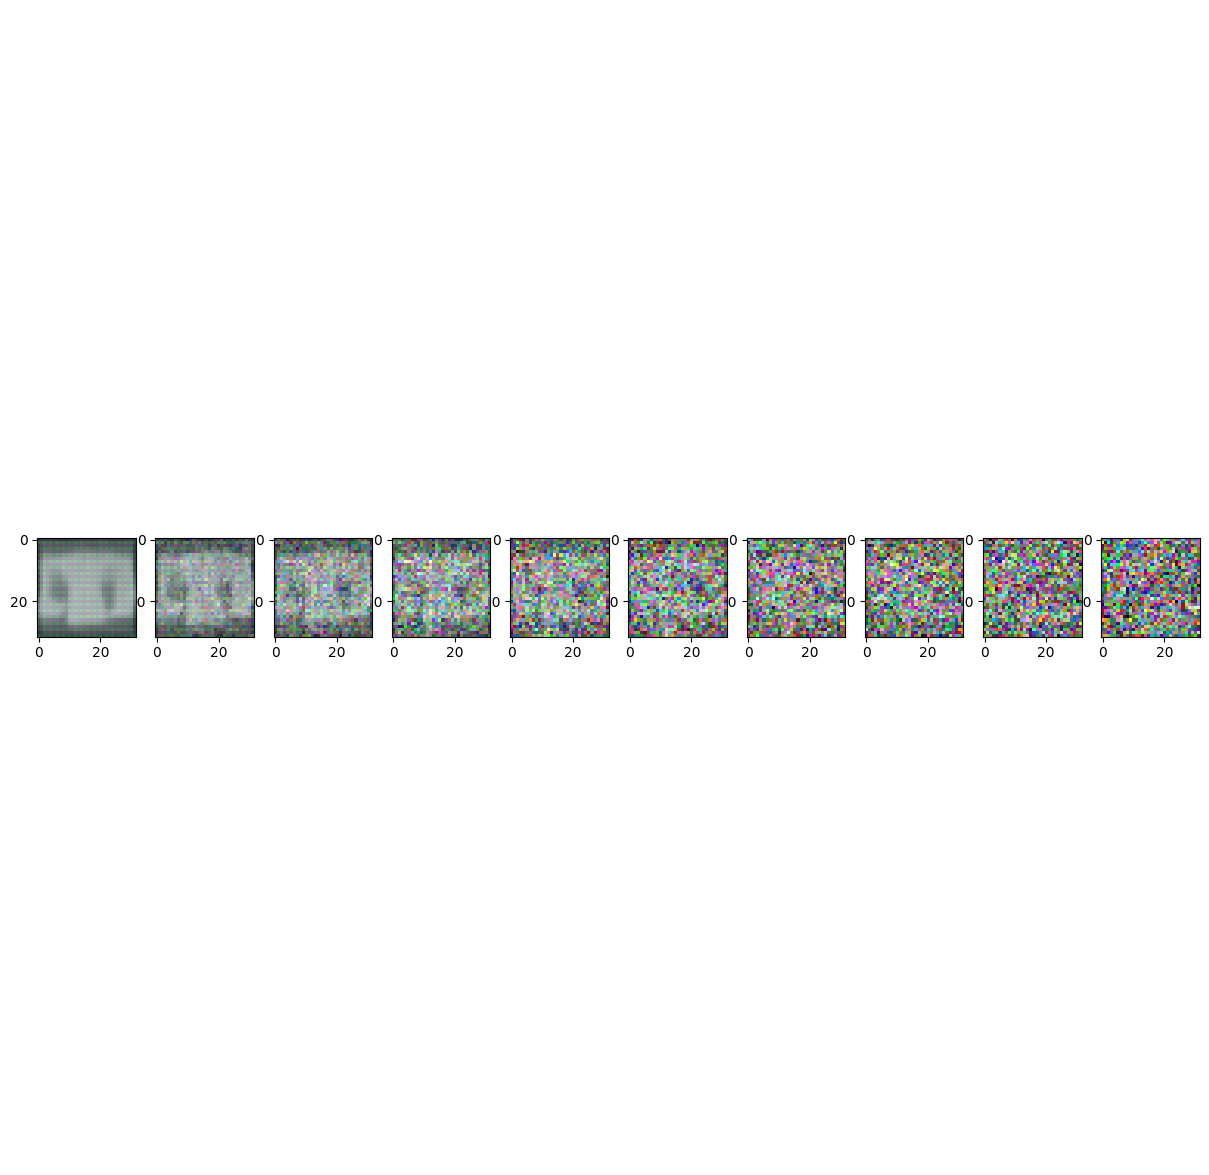


Starting Epoch 20/20
Epoch 20 | Step 0 | Loss: 0.0868
Epoch 20 | Step 100 | Loss: 0.0831
Epoch 20 | Step 200 | Loss: 0.0837
Epoch 20 | Step 300 | Loss: 0.0844
Epoch 20 | Step 400 | Loss: 0.0843
Epoch 20 | Step 500 | Loss: 0.0914


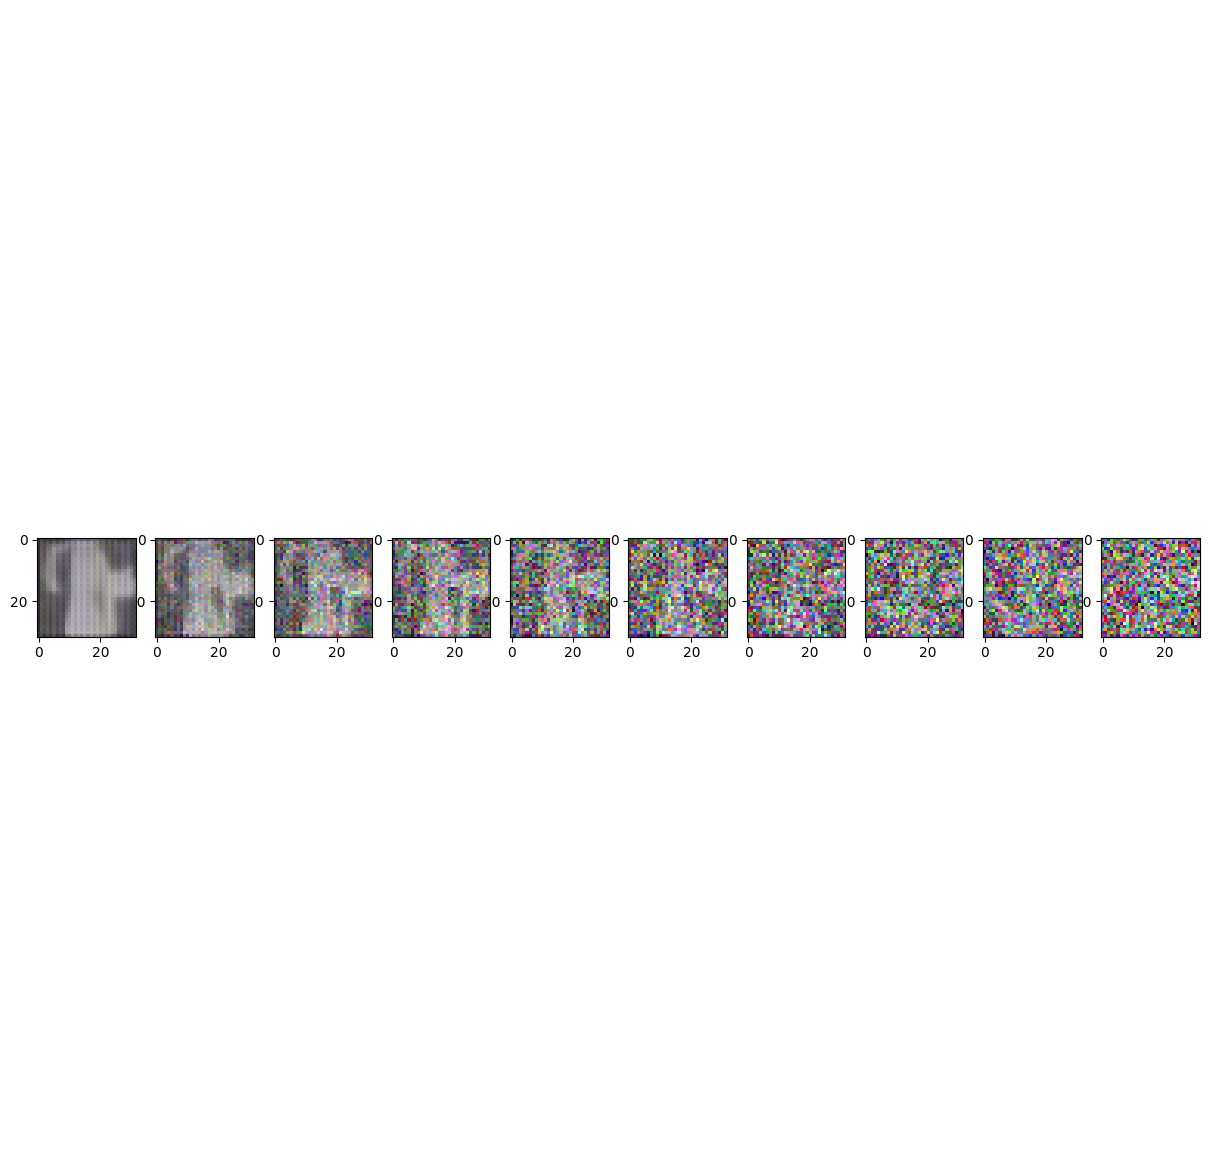

In [8]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = Adam(model.parameters(), lr=0.001)
epochs = 20

for epoch in range(epochs):
    print(f"\nStarting Epoch {epoch+1}/{epochs}")

    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()

        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        loss = get_loss(model, batch[0].to(device), t)

        loss.backward()
        optimizer.step()


        if step % 100 == 0:
            print(f"Epoch {epoch+1} | Step {step} | Loss: {loss.item():.4f}")

    # sampling every epoch
    sample_plot_image()